[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpi-techfundamentals/fall2018-materials/blob/master/10-deep-learning/04-pytorch-mnist.ipynb)


In [1]:
# Install ngrok
!pip install pyngrok

In [2]:
# Set ngrok authtoken
from pyngrok import ngrok
ngrok.set_auth_token("2uoXzYjUu0hqsdPDFzrb2NWPI8r_7u5SXUG7vdy9hxi59s1DL")

# Function to start ngrok
def start_ngrok():
    # Start the ngrok process with subprocess, specifying that ngrok should tunnel HTTP traffic to port 5000
    ngrok_process = subprocess.Popen(['ngrok', 'http', '5000'])
    # Delay the script for 4 seconds to allow ngrok time to initialize and start the tunnel
    time.sleep(4)
    # Fetch the ngrok tunnel information using an HTTP GET request to ngrok's local API
    response = requests.get('http://localhost:4040/api/tunnels')
    # Parse the JSON response to get the details of the tunnel
    tunnel_info = response.json()
    # Extract the public URL where the ngrok tunnel is accessible
    public_url = tunnel_info['tunnels'][0]['public_url']
    # Print the ngrok tunnel URL to the console
    print(" * ngrok tunnel URL:", public_url)
    # Return the public URL for use elsewhere in the script
    return public_url


In [3]:
# Step 1: Importing Libraries
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.preprocessing import image
import numpy as np
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from google.colab import files

import os
import shutil
from shutil import copyfile
import zipfile
from tqdm import tqdm

from sklearn.model_selection import train_test_split

# PLEASE UPLOAD kaggle.json from your zipped folder

In [4]:
print("Please upload kaggle.json from your zipped folder")
files.upload()  # Upload kaggle.json here

# Make a .kaggle directory
os.makedirs('/root/.kaggle', exist_ok=True)

# Move kaggle.json into it
!mv kaggle.json /root/.kaggle/kaggle.json

# Set permission
!chmod 600 /root/.kaggle/kaggle.json

!pip install -q kaggle

!kaggle datasets download -d jakeshbohaju/brain-tumor -p datasets --unzip



Please upload kaggle.json from your zipped folder


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor
License(s): CC-BY-NC-SA-4.0
  0% 0.00/14.0M [00:00<?, ?B/s]
100% 14.0M/14.0M [00:00<00:00, 804MB/s]


In [5]:
base_dir = 'datasets/Brain Tumor'

In [6]:
df = pd.read_csv("datasets/Brain Tumor.csv")[['Image', 'Class']]
display(df.head())
print(df.shape)

,Image,Class
0,Image1,0
1,Image2,0
2,Image3,1
3,Image4,1
4,Image5,0


(3762, 2)


In [7]:
# Split Training + Validation with Testing Set
def split_size(df, size):
    return int(size * len(df))


train_labels = df['Class'].values[:split_size(df, 0.8)]
train_file_names = df['Image'].values[:split_size(df, 0.8)]

val_labels = df['Class'].values[split_size(df, 0.8):split_size(df, 0.9)]
val_file_names = df['Image'].values[split_size(df, 0.8):split_size(df, 0.9)]

test_labels = df['Class'].values[split_size(df, 0.9):]
test_file_names = df['Image'].values[split_size(df, 0.9):]

In [8]:
def split_array_labels(arr_image, arr_label):
    arr_image_0 = arr_image[np.where(arr_label==0)]
    arr_image_1 = arr_image[np.where(arr_label==1)]
    return {'0':arr_image_0, '1':arr_image_1}

In [9]:
train_arr_dict = split_array_labels(train_file_names, train_labels)
val_arr_dict = split_array_labels(val_file_names, val_labels)
test_arr_dict = split_array_labels(test_file_names, test_labels)
def create_empty_directories(base_dir):
    # in case you want to run it several times, delete the directory and create new one
    check_exist_path = os.path.join(base_dir, '_MODELLING')
    if os.path.isdir(check_exist_path):
        shutil.rmtree(check_exist_path)
        print("Remove old directories")

    for label in ['0','1']:
        training_dir = os.path.join(base_dir, '_MODELLING', 'training', label)
        validation_dir = os.path.join(base_dir, '_MODELLING', 'validation', label)
        testing_dir = os.path.join(base_dir, '_MODELLING', 'testing', label)



        os.makedirs(training_dir)
        os.makedirs(validation_dir)
        os.makedirs(testing_dir)
    print(f"Created empty  training, validation and testing directories")
create_empty_directories('/kaggle/working')

Remove old directories
Created empty  training, validation and testing directories


In [10]:
def split_data(SOURCE_DIR, train_arr_dict, val_arr_dict, test_arr_dict):
    for label in tqdm(['0','1']):
        for file_name in train_arr_dict[label]:
            file_name = f"{file_name}.jpg"
            source = os.path.join(SOURCE_DIR, 'Brain Tumor', file_name)
            destination = os.path.join('/kaggle/working', '_MODELLING', 'training', label, file_name)
            copyfile(source, destination)

        for file_name in val_arr_dict[label]:
            file_name = f"{file_name}.jpg"
            source = os.path.join(SOURCE_DIR, 'Brain Tumor', file_name)
            destination = os.path.join('/kaggle/working', '_MODELLING', 'validation', label, file_name)
            copyfile(source, destination)

        for file_name in test_arr_dict[label]:
            file_name = f"{file_name}.jpg"
            source = os.path.join(SOURCE_DIR, 'Brain Tumor', file_name)
            destination = os.path.join('/kaggle/working', '_MODELLING', 'testing', label, file_name)
            copyfile(source, destination)
    print(f"Created training, validation and testing directories containing images")

split_data(base_dir,train_arr_dict,val_arr_dict,test_arr_dict)

100%|██████████| 2/2 [00:00<00:00,  6.51it/s]

Created training, validation and testing directories containing images


In [11]:
base_dir  = '/kaggle/working/_MODELLING'
os.chdir(base_dir)

mytrain_test_list = []
mylabels_list = []
myitem_list = []
vis_images = []; vis_labels =[]

train_test_list = tf.io.gfile.listdir(base_dir)
for train_test in train_test_list:
    path1 = os.path.join(base_dir, train_test)
    label_list = tf.io.gfile.listdir(path1)
    for label in label_list:
        my_path = os.path.join(path1, label)
        item_files = os.listdir(my_path)

        mytrain_test_list.append(train_test)
        mylabels_list.append(label)
        myitem_list.append(len(item_files))

        my_files = item_files[0:5]
        for file in my_files:
            vis_images.append(os.path.join(my_path, file))
            vis_labels.append(label)

pd.DataFrame({'Tran Test':mytrain_test_list, 'Labels':mylabels_list, \
              'Number of Items':myitem_list})

,Tran Test,Labels,Number of Items
0,validation,0,119
1,validation,1,257
2,testing,0,138
3,testing,1,239
4,training,0,1822
5,training,1,1187


In [12]:
train_dir = '/kaggle/working/_MODELLING/training'
val_dir = '/kaggle/working/_MODELLING/validation'

# Data Augmentation and Preprocessing
data_gen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_data = data_gen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = data_gen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

Found 3009 images belonging to 2 classes.
Found 376 images belonging to 2 classes.


In [13]:
# Step 3: Model Architecture
# Load MobileNetV2
mobilenet = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
mobilenet.trainable = False  # Freeze base model layers

# Build Model
model = Sequential([
    mobilenet,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Step 4: Compile Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Step 5: Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 72s 561ms/step - accuracy: 0.6824 - loss: 4.1817 - val_accuracy: 0.8005 - val_loss: 0.4539
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 452ms/step - accuracy: 0.8118 - loss: 0.4594 - val_accuracy: 0.7793 - val_loss: 0.4675
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 48s 505ms/step - accuracy: 0.8260 - loss: 0.4046 - val_accuracy: 0.8378 - val_loss: 0.3739
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 437ms/step - accuracy: 0.8410 - loss: 0.3622 - val_accuracy: 0.7739 - val_loss: 0.4256
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 458ms/step - accuracy: 0.8211 - loss: 0.3612 - val_accuracy: 0.8484 - val_loss: 0.3466
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 448ms/step - accuracy: 0.8554 - loss: 0.3218 - val_accuracy: 0.8404 - val_loss: 0.3230
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 457ms/step - accuracy: 0.8300 - loss: 0.3317 - val_accuracy: 0.8564 - val_loss: 0.3399
Epoch 8/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 447ms/step - accuracy: 0.8494 - loss: 0.3216 - val_accu

In [14]:
# Step 6: Save Model
model.save('brain_tumor_model.h5')

In [15]:
# Load the model
loaded_model = keras.models.load_model('brain_tumor_model.h5')
test_dir = '/kaggle/working/_MODELLING/testing'

# Assuming 'test_dir' contains your test images
test_data_gen = ImageDataGenerator(rescale=1.0/255)  # Only rescaling

test_data = test_data_gen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,  # Adjust as needed
    class_mode='binary',  # Adjust if not binary classification
    shuffle=False  # Important: Keep the order for evaluation
)

Found 377 images belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step


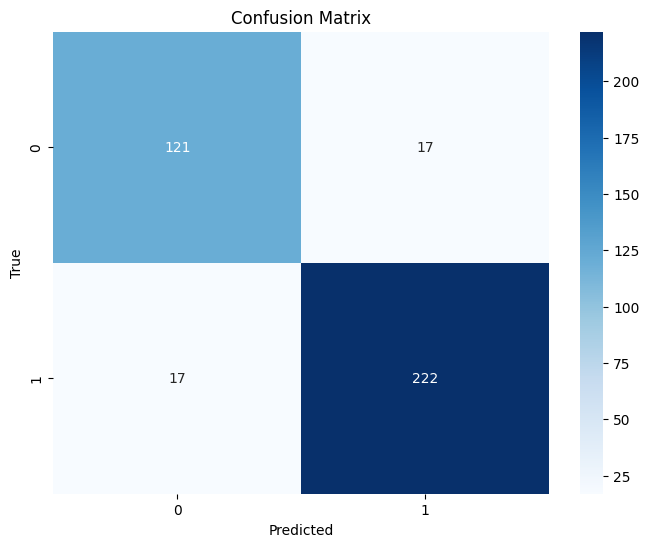

In [16]:
# prompt: Produce a confusion matrix for the prediction made on the test data

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels
y_true = test_data.classes

# Get predicted labels
y_pred = (loaded_model.predict(test_data) > 0.5).astype("int32").flatten()

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [17]:
# THIS SECTION FOR TESTING ONLY
# print("Please upload the image you wish to be evaluated and name it test.jpg")
# files.upload()
# # Preprocess the image
# img_path = '/content/Ptest.jpg'  # Replace with the actual path
# img = image.load_img(img_path, target_size=(224, 224))
# img_array = image.img_to_array(img)
# img_array = np.expand_dims(img_array, axis=0)
# img_array /= 255.0

# # Make a prediction
# prediction = loaded_model.predict(img_array)

# # Interpret the prediction
# if prediction[0][0] > 0.8:
#     print("Brain tumor detected")
# else:
#     print("No brain tumor detected")

# imgplot = plt.imshow(img)
# plt.show()

SyntaxError: incomplete input (<ipython-input-17-08ab088c2f79>, line 1)

In [18]:
from flask import Flask, request, jsonify, render_template_string
import numpy as np
from tensorflow.keras.preprocessing import image
from PIL import Image
import tensorflow as tf
import io
from pyngrok import ngrok

# Load the model once at startup
model = tf.keras.models.load_model('brain_tumor_model.h5')

# HTML from your template
html_template = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Brain Tumor Detection</title>
    <style>
        body {
            margin: 0;
            font-family: 'Segoe UI', sans-serif;
            background-color: #f4f4f4;
        }

        header {
            background-color: #2c3e50;
            color: white;
            padding: 20px;
            text-align: center;
        }

        .container {
            display: flex;
            min-height: calc(100vh - 100px);
        }

        .sidebar {
            width: 250px;
            background-color: #34495e;
            color: white;
            padding: 20px;
            box-shadow: 2px 0 5px rgba(0,0,0,0.1);
        }

        .sidebar h2 {
            font-size: 20px;
            margin-bottom: 15px;
        }

        .sidebar p {
            font-size: 14px;
            color: #bdc3c7;
        }

        .main-content {
            flex: 1;
            padding: 30px;
            background-color: #ffffff;
        }

        .upload-section {
            margin-bottom: 30px;
        }

        .upload-section input[type="file"] {
            margin-top: 10px;
        }

        .preview-container {
            display: flex;
            flex-wrap: wrap;
            gap: 20px;
            margin-top: 20px;
        }
        .preview-container {
            margin-top: 30px;
            display: flex;
            flex-wrap: wrap;
            justify-content: center;
            gap: 20px;
        }
        .preview-container img {
            max-width: 250px;
            border: 2px solid #ccc;
            padding: 10px;
            background-color: #fff;
        }

        .image-card {
            background-color: #f9f9f9;
            border: 1px solid #ccc;
            padding: 15px;
            width: 250px;
            box-shadow: 0 2px 5px rgba(0,0,0,0.05);
        }

        .image-card img {
            max-width: 100%;
            height: auto;
            display: block;
            margin-bottom: 10px;
        }

        textarea {
            width: 100%;
            height: 60px;
            resize: vertical;
            margin-bottom: 10px;
        }

        .result {
            font-size: 14px;
            color: #333;
        }

        footer {
            background-color: #2c3e50;
            color: white;
            text-align: center;
            padding: 15px;
        }
    </style>
</head>
<body>

    <header>
        <h1>Brain Tumor Detection System</h1>
    </header>

    <div class="container">
        <!-- Sidebar -->
        <aside class="sidebar">
            <h2>Instructions</h2>
            <p>Upload brain MRI images to analyze for possible tumor detection.</p>
            <p>You can add notes for each image and view preliminary results.</p>
        </aside>

        <!-- Main content -->
        <main class="main-content">
            <section class="upload-section">
                <h2>Upload MRI Images</h2>
                <input type="file" id="imageInput" accept="image/*" multiple>

    <div class="preview-container" id="previewContainer"></div>
        </main>
    </div>
    <script>
    const imageInput = document.getElementById('imageInput');
    const previewContainer = document.getElementById('previewContainer');

    imageInput.addEventListener('change', function () {
        previewContainer.innerHTML = '';
        const files = this.files;

        if (files.length > 0) {
            Array.from(files).forEach(file => {
                const reader = new FileReader();
                reader.onload = function (e) {
                    // Create card container
                    const card = document.createElement('div');
                    card.className = 'image-card';

                    // Create and append image preview
                    const img = document.createElement('img');
                    img.src = e.target.result;

                    // Create and append notes area
                    const note = document.createElement('textarea');
                    note.placeholder = 'Enter notes or observations here...';

                    // Create result div
                    const result = document.createElement('div');
                    result.className = 'result';
                    result.innerHTML = "<strong>Preliminary Result:</strong> <em>Analyzing...</em>";

                    // Append elements to card
                    card.appendChild(img);
                    card.appendChild(note);
                    card.appendChild(result);
                    previewContainer.appendChild(card);

                    // Send image to server for prediction
                    const formData = new FormData();
                    formData.append('file', file);

                    fetch('/predict', {
                        method: 'POST',
                        body: formData
                    })
                    .then(response => response.json())
                    .then(data => {
                        result.innerHTML = `<strong>Preliminary Result:</strong> <em>${data.result}</em>`;
                    })
                    .catch(error => {
                        result.innerHTML = `<strong>Error:</strong> Unable to process image.`;
                        console.error('Prediction error:', error);
                    });
                };
                reader.readAsDataURL(file);
            });
        }
    });
</script>


    <footer>
        <p>&copy; 2025 BrainScanAI.Group Project Industrial Skills and Professional Issues .</p>
    </footer>
    </body>
</html>"""

app = Flask(__name__)

@app.route('/')
def index():
    return render_template_string(html_template)

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return jsonify({'error': 'No file uploaded'}), 400

    file = request.files['file']
    if file.filename == '':
        return jsonify({'error': 'Empty filename'}), 400

    try:
        img = Image.open(file.stream).resize((224, 224)).convert('RGB')
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) / 255.0

        prediction = model.predict(img_array)
        result = "Brain tumor detected" if prediction[0][0] > 0.8 else "No brain tumor detected"
        return jsonify({'result': result})
    except Exception as e:
        return jsonify({'error': str(e)}), 500

def start_ngrok():
    url = ngrok.connect(5000)
    return url

if __name__ == '__main__':
    public_url = start_ngrok()
    print(f" * Access the web app at: {public_url}")
    app.run(port=5000)


 * Access the web app at: NgrokTunnel: "https://cded-34-143-143-187.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [16/May/2025 00:32:31] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/May/2025 00:32:32] "GET /favicon.ico HTTP/1.1" 404 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


INFO:werkzeug:127.0.0.1 - - [16/May/2025 00:32:59] "POST /predict HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


...

INFO:werkzeug:127.0.0.1 - - [16/May/2025 00:33:59] "POST /predict HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [16/May/2025 00:34:09] "GET / HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


INFO:werkzeug:127.0.0.1 - - [16/May/2025 00:34:26] "POST /predict HTTP/1.1" 200 -


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


INFO:werkzeug:127.0.0.1 - - [16/May/2025 00:34:49] "POST /predict HTTP/1.1" 200 -
